In [1]:
# Import
import numpy as np
import pandas as pd
# import xarray as xr
import matplotlib.pyplot as plt
import datetime, os
from cartopy import crs as ccrs
from cartopy import feature as cfeature
# import seaborn as sns 
# from tabulate import tabulate
import sys
import re
from IPython.display import clear_output
import datetime
import textwrap
import csv

In [2]:
# Get current directory
current_directory = os.getcwd()
#print(current_directory)

# Specify the path to the folder you want to save data to 
Figures = os.path.join(current_directory, 'figures')
Files = os.path.join(current_directory, 'output_txt_files')
CSV = os.path.join(current_directory, 'csv_files')

#NOTE: copy and past permanent_txt_files from previous export

# Create directories only if they don't exist
os.makedirs(Figures, exist_ok=True)
os.makedirs(Files, exist_ok=True)
os.makedirs(CSV, exist_ok=True)

In [3]:
# labels corresponding to missing data
na_values = ['No observation', 'No observations', 'No Observation', 'No Observations',
             'no observation', 'no observations', 'None given', 'none given', 'None Given', 'none',
             'none recorded', 'not recorded', 'None recorded', 'Not given', 'not given', ' ', 'N.A.', 
             'Na', 'Does not say', 'N.A', 'Deos not say', 'N A', 'NA']

export_csv = 'logentries-export-2025-10-21.csv'

og_df = pd.read_csv(os.path.join(CSV, export_csv), na_values=na_values, low_memory=False)

# Combine using column names
og_df['DateTime'] = pd.to_datetime(og_df['Entry Date'] + ' ' + og_df['Local Time'], errors='coerce')
og_df.columns

Index(['ID', 'LogBook ID', 'Page', 'Entry Date', 'Local Time', 'Latitude',
       'Longitude', 'Depth', 'Depth Unit', 'Bottom', 'Current', 'Landmark',
       'Ship Heading/Course', 'Wind Direction', 'Wind Speed/Force',
       'Sea State', 'Cloud Cover', 'Weather', '2. Ship Heading/Course',
       '2. Wind Direction', '2. Wind Speed/Force', '2. Sea State',
       '2. Cloud Cover', '2. Weather', '3. Ship Heading', '3. Wind Direction',
       '3. Wind Speed/Force', '3. Sea State', '3. Cloud Cover', '3. Weather',
       'Ship Sightings', 'Instrumental Observations',
       'Miscellaneous Observations', 'DateTime'],
      dtype='object')

In [4]:
# labels corresponding to missing data
na_values = ['No observation', 'No observations', 'No Observation', 'No Observations',
             'no observation', 'no observations', 'None given', 'none given', 'None Given', 'none',
             'none recorded', 'not recorded', 'None recorded', 'Not given', 'not given', ' ', 'N.A.', 
             'Na', 'Does not say', 'N.A', 'Deos not say', 'N A', 'NA']

export_csv = 'logentries-export-2025-10-21.csv'

og_df = pd.read_csv(os.path.join(CSV, export_csv), na_values=na_values, low_memory=False)

# Combine using column names
og_df['DateTime'] = pd.to_datetime(og_df['Entry Date'] + ' ' + og_df['Local Time'], errors='coerce')
og_df.columns

Index(['ID', 'LogBook ID', 'Page', 'Entry Date', 'Local Time', 'Latitude',
       'Longitude', 'Depth', 'Depth Unit', 'Bottom', 'Current', 'Landmark',
       'Ship Heading/Course', 'Wind Direction', 'Wind Speed/Force',
       'Sea State', 'Cloud Cover', 'Weather', '2. Ship Heading/Course',
       '2. Wind Direction', '2. Wind Speed/Force', '2. Sea State',
       '2. Cloud Cover', '2. Weather', '3. Ship Heading', '3. Wind Direction',
       '3. Wind Speed/Force', '3. Sea State', '3. Cloud Cover', '3. Weather',
       'Ship Sightings', 'Instrumental Observations',
       'Miscellaneous Observations', 'DateTime'],
      dtype='object')

In [31]:
h_subset = og_df[og_df['LogBook ID'] == 'Leonidas (ship) 1842-1845']
#h_subset

In [32]:
# replace DateTime-strings that end with ' nan' with np.nan
df_dt = h_subset.copy()
df_dt.loc[df_dt.DateTime.astype(str).str.endswith(' nan'), 'DateTime'] = np.nan

In [33]:
# converting 'DateTime' column to actual DateTime and calling it "Entry Date Time"
df_dt['Entry Date Time'] = pd.to_datetime(df_dt.DateTime, format = '%Y-%m-%d %H:%M:%S')
# deleting row "DateTime"
df_dt.drop('DateTime',axis=1)

,ID,LogBook ID,Page,Entry Date,Local Time,Latitude,Longitude,Depth,Depth Unit,Bottom,...,3. Ship Heading,3. Wind Direction,3. Wind Speed/Force,3. Sea State,3. Cloud Cover,3. Weather,Ship Sightings,Instrumental Observations,Miscellaneous Observations,Entry Date Time
107665,26342,Leonidas (ship) 1842-1845,N/a,1845-05-28,12:00:00,N/a,N/a,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1845-05-28 12:00:00
107666,26341,Leonidas (ship) 1842-1845,N/a,1845-05-27,12:00:00,40 38 N,N/a,NaN,NaN,NaN,...,NaN,NaN,Light winds,NaN,NaN,NaN,NaN,NaN,NaN,1845-05-27 12:00:00
107667,26340,Leonidas (ship) 1842-1845,N/a,1845-05-26,12:00:00,38 36 N,72 05 W,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1845-05-26 12:00:00
107668,26339,Leonidas (ship) 1842-1845,N/a,1845-05-25,12:00:00,37 03 N,73 00 W,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1845-05-25 12:00:00
107669,26338,Leonidas (ship) 1842-1845,N/a,1845-05-24,12:00:00,36 20 N,N/a,NaN,NaN,NaN,...,NaN,NaN,Gales,NaN,NaN,NaN,NaN,NaN,NaN,1845-05-24 12:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110112,23874,Leonidas (ship) 1842-1845,N/a,1845-02-21,12:00:00,47 25 S,104 58 W,NaN,NaN,NaN,...,NaN,NW,Light winds,NaN,NaN,Foggy weather,NaN,NaN,NaN,1845-02-21 12:00:00
110113,23873,Leonidas (ship) 1842-1845,N/a,1845-02-20,12:00:00,45 27 S,107 25 W,NaN,NaN,NaN,...,NaN,NaN,Fresh winds,NaN,NaN,Foggy weather,NaN,NaN,NaN,1845-02-20 12:00:00
110114,23872,Leonidas (ship) 1842-1845,N/a,1845-02-19,12:00:00,45 50 S,110 14 W,NaN,NaN,NaN,...,NaN,WSW,Winds,NaN,NaN,NaN,NaN,NaN,NaN,1845-02-19 12:00:00
110115,23871,Leonidas (ship) 1842-1845,N/a,1845-02-18,12:00:00,45 10 S,113 38 W,NaN,NaN,NaN,...,NaN,SE,Strong winds,NaN,NaN,NaN,NaN,NaN,NaN,1845-02-18 12:00:00


In [34]:
from utils.cleaning import dms_to_decimal

df = df_dt.copy()
df['Latitude_decimal']=df['Latitude'].apply(dms_to_decimal)
df['Longitude_decimal']=df['Longitude'].apply(dms_to_decimal)

In [35]:
df.columns

Index(['ID', 'LogBook ID', 'Page', 'Entry Date', 'Local Time', 'Latitude',
       'Longitude', 'Depth', 'Depth Unit', 'Bottom', 'Current', 'Landmark',
       'Ship Heading/Course', 'Wind Direction', 'Wind Speed/Force',
       'Sea State', 'Cloud Cover', 'Weather', '2. Ship Heading/Course',
       '2. Wind Direction', '2. Wind Speed/Force', '2. Sea State',
       '2. Cloud Cover', '2. Weather', '3. Ship Heading', '3. Wind Direction',
       '3. Wind Speed/Force', '3. Sea State', '3. Cloud Cover', '3. Weather',
       'Ship Sightings', 'Instrumental Observations',
       'Miscellaneous Observations', 'DateTime', 'Entry Date Time',
       'Latitude_decimal', 'Longitude_decimal'],
      dtype='object')

Saved: /home/finn.wimberly/Documents/whaling_logs/20251021_export/figures/inspect_Leonidas


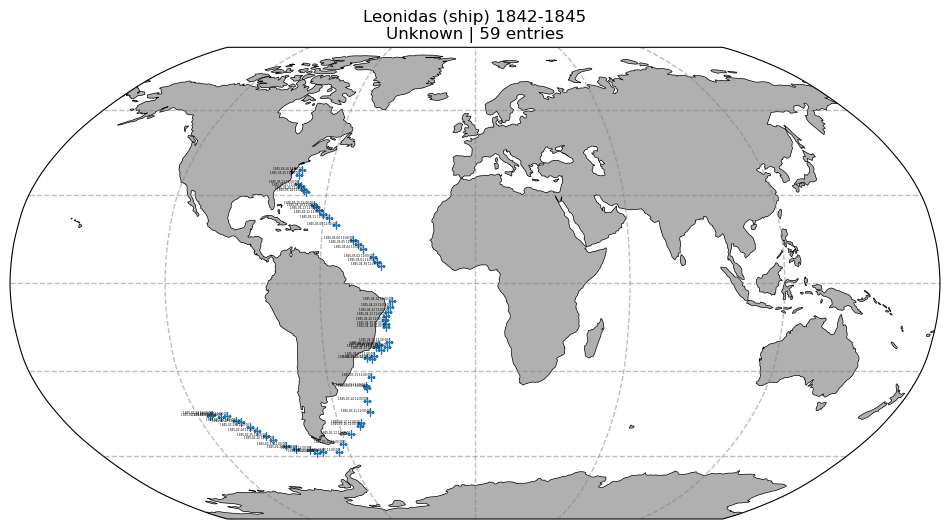

In [37]:
from utils.cleaning import plot_logbook

_ = plot_logbook(
    # df, "Herald (Ship)  1834-1837",
    df, "Leonidas (ship) 1842-1845",
    years = [1842, 1843, 1844, 1845],
    annotate=True,                
    annotate_field="Entry Date Time",
    annotate_max=1500,  
    figures_dir = Figures,
    save=True,
    filename="inspect_Leonidas",
    dpi=500,
)

In [30]:
df['Entry Date'] = pd.to_datetime(df['Entry Date'])
df_1834 = df[df['Entry Date'].dt.year == 1834]
df_1835 = df[df['Entry Date'].dt.year == 1835]
df_1836 = df[df['Entry Date'].dt.year == 1836]
df_1837 = df[df['Entry Date'].dt.year == 1837]

In [23]:
from utils.meta import plot_logbook_with_options

plot_logbook_with_options(df_1834, "Herald (Ship)  1834-1837", save=True, save_path = Figures, color_by = 'Entry Date',  title=f'Voyage – Herald 1834')

(<Figure size 1200x800 with 2 Axes>,
 <GeoAxes: title={'center': 'Voyage – Herald 1834'}>)

Starting tasks for Sue to take care of:
- change date to correct year in 127545
- 1834 appears to have more eclectic errors we can deal with those later
- invert latitudes from S to N from 1835-05-10 to 1835-08-19
- invert latitudes from N to S from 1835-09-05 to 1835-10-30
- Most of 1836 and 1837 appear to be correct!

In [ ]:
from utils.meta import plot_logbook_with_options

#select dataframe to plot from
tier = 4
plot_df = df.copy()

#select logbook to plot
selected_logbook = 'Young Phenix (Ship) 1836-1840'

In [ ]:
plot_logbook_with_options(plot_df, selected_logbook, save=False, color_by = 'Entry Date',  title=f'Voyage – {selected_logbook}')